In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

import sys
sys.path.append("..")
from analysis_utils import *

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Adjust font sizes:
# Set global sizes
plt.rcParams.update({
    'font.size': 18,          # Base font size
    'axes.titlesize': 24,     # Title size
    'axes.labelsize': 20,     # X and Y label size
    'xtick.labelsize': 16,    # X tick label size
    'ytick.labelsize': 16,    # Y tick label size
    'legend.fontsize': 16,    # Legend size
    'lines.linewidth': 3,     # Thicker lines for visibility
    'lines.markersize': 10    # Larger markers
})        

First define the two experiments to be compared:

In [4]:
results_1 = "./analysis_results/2022_barn_2secs_myca_quantile_1_16"
results_2 = "./analysis_results/2022_lake_2secs_myca_quantile_1_28"
exp_1_name = "Barn"
exp_2_name = "Lake"

In [5]:
chirp_attributes_1 = pd.read_csv(f"{results_1}/test_set_chirp_attributes.csv")
chirp_attributes_1 = pd.read_csv(f"{results_1}/all_chirp_measures_scaled_quantile.csv")
chirp_attributes_1 = pd.read_csv(f"{results_1}/all_chirp_measures_scaled_robust.csv")
idiom_boundaries_1 = pd.read_csv(f"{results_1}/idiom_boundaries.csv", header=None)
confidence_measures_1 = pd.read_csv(f"{results_1}/chirp_prediction_confidence_measures.csv")

chirp_attributes_2 = pd.read_csv(f"{results_2}/test_set_chirp_attributes.csv")
chirp_attributes_2 = pd.read_csv(f"{results_2}/all_chirp_measures_scaled_quantile.csv")
chirp_attributes_2 = pd.read_csv(f"{results_2}/all_chirp_measures_scaled_robust.csv")
idiom_boundaries_2 = pd.read_csv(f"{results_2}/idiom_boundaries.csv", header=None)
confidence_measures_2 = pd.read_csv(f"{results_2}/chirp_prediction_confidence_measures.csv")

In [6]:
combined_chirp_attributes = pd.concat([chirp_attributes_1, chirp_attributes_2], ignore_index=False).reset_index()
combined_chirp_attributes.rename({"index": "OriginalIndex"}, axis=1, inplace=True)
idiom_boundaries_attributes = pd.concat([idiom_boundaries_1, idiom_boundaries_2], ignore_index=False).reset_index()
idiom_boundaries_attributes.rename({"index": "OriginalIndex"}, axis=1, inplace=True)
confidence_measures_attributes = pd.concat([confidence_measures_1, confidence_measures_2], ignore_index=False).reset_index()
confidence_measures_attributes.rename({"index": "OriginalIndex"}, axis=1, inplace=True)
combined_chirp_attributes

,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,...,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom
0,0,0.097902,-1.268293,0.219452,0.268808,0.767059,-0.210968,0.357437,0.132581,0.219721,...,0.495979,1.071590,1.285666,-0.220161,16693.0,0.0,4,False,False,False
1,1,0.443249,0.317073,-0.932709,-1.041243,-0.018583,0.277708,-0.489829,-0.471865,-0.932381,...,-0.750206,-0.759809,-0.621397,0.261875,16693.0,1.0,7,False,False,False
2,2,0.525013,0.292683,-0.502392,-0.614336,0.080624,0.285283,-0.429633,0.115052,-0.502085,...,-0.263291,0.110701,-0.045891,0.321761,16693.0,2.0,7,False,False,False
3,3,0.614309,-0.536585,-0.552165,-0.722762,0.139114,0.574692,-0.340954,0.747337,-0.551856,...,-0.648368,-0.518778,-0.542878,0.658009,16693.0,3.0,7,False,False,False
4,4,0.706832,0.512195,-0.461065,-0.425638,0.121155,-0.419993,-1.306397,1.890789,-0.460761,...,-0.550110,-0.389833,-0.482727,-0.448275,16693.0,4.0,7,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14984,757,-0.159453,0.600000,-1.253421,-1.199170,0.481405,-2.500203,-1.753066,0.908331,-1.245167,...,-0.787953,-0.880101,-0.725358,-0.591347,1090.0,9.0,1,False,False,False
14985,758,-0.067198,0.150000,-0.124970,0.084144,-1.074635,0.648007,0.178209,-0.747995,-0.120980,...,-0.328187,-0.547830,-0.449443,1.393880,1090.0,10.0,5,False,False,False
14986,759,0.133257,0.250000,-0.144417,0.030290,-0.700754,0.569081,-0.014897,-0.137883,-0.140354,...,-0.288372,-0.024411,-0.383145,0.057541,1090.0,11.0,1,False,False,False
14987,760,0.211845,-0.600000,0.048713,-0.024354,-0.008542,0.461981,0.838935,-0.279334,0.052047,...,-0.149269,0.139225,-0.111710,-0.407705,1090.0,12.0,9,False,False,False


In [7]:
for dataframe, df_1 in [(combined_chirp_attributes, chirp_attributes_1), 
                        (idiom_boundaries_attributes, idiom_boundaries_1), 
                        (confidence_measures_attributes, confidence_measures_1)]:
    dataframe["original_df"] = dataframe.apply(lambda x: 1 if x.name < len(df_1) else 2, axis=1)
combined_chirp_attributes

,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,...,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom,original_df
0,0,0.097902,-1.268293,0.219452,0.268808,0.767059,-0.210968,0.357437,0.132581,0.219721,...,1.071590,1.285666,-0.220161,16693.0,0.0,4,False,False,False,1
1,1,0.443249,0.317073,-0.932709,-1.041243,-0.018583,0.277708,-0.489829,-0.471865,-0.932381,...,-0.759809,-0.621397,0.261875,16693.0,1.0,7,False,False,False,1
2,2,0.525013,0.292683,-0.502392,-0.614336,0.080624,0.285283,-0.429633,0.115052,-0.502085,...,0.110701,-0.045891,0.321761,16693.0,2.0,7,False,False,False,1
3,3,0.614309,-0.536585,-0.552165,-0.722762,0.139114,0.574692,-0.340954,0.747337,-0.551856,...,-0.518778,-0.542878,0.658009,16693.0,3.0,7,False,False,False,1
4,4,0.706832,0.512195,-0.461065,-0.425638,0.121155,-0.419993,-1.306397,1.890789,-0.460761,...,-0.389833,-0.482727,-0.448275,16693.0,4.0,7,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14984,757,-0.159453,0.600000,-1.253421,-1.199170,0.481405,-2.500203,-1.753066,0.908331,-1.245167,...,-0.880101,-0.725358,-0.591347,1090.0,9.0,1,False,False,False,2
14985,758,-0.067198,0.150000,-0.124970,0.084144,-1.074635,0.648007,0.178209,-0.747995,-0.120980,...,-0.547830,-0.449443,1.393880,1090.0,10.0,5,False,False,False,2
14986,759,0.133257,0.250000,-0.144417,0.030290,-0.700754,0.569081,-0.014897,-0.137883,-0.140354,...,-0.024411,-0.383145,0.057541,1090.0,11.0,1,False,False,False,2
14987,760,0.211845,-0.600000,0.048713,-0.024354,-0.008542,0.461981,0.838935,-0.279334,0.052047,...,0.139225,-0.111710,-0.407705,1090.0,12.0,9,False,False,False,2


Visualize how the two experiments are distributed in a 2-D projection:

In [8]:
import umap
combined_chirp_attributes_embedded = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(combined_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy())

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


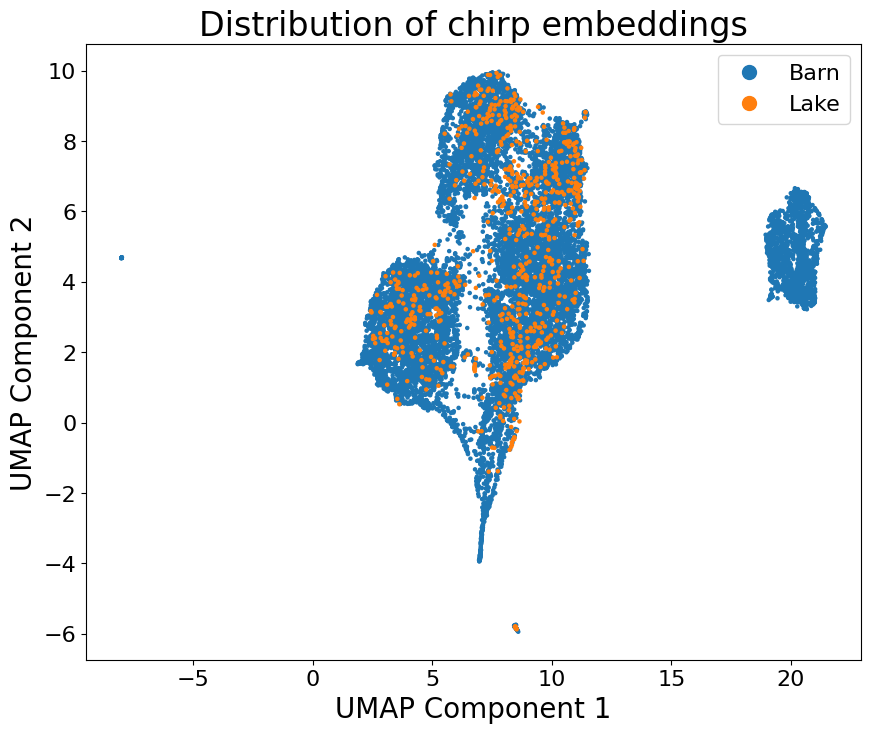

In [9]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(combined_chirp_attributes_embedded[:, 0], 
                      combined_chirp_attributes_embedded[:, 1], 
                      c=combined_chirp_attributes["original_df"], 
                      cmap="tab10",
                      vmin=1,
                      vmax=10,
                      s=5,
                      )
plt.title(f"Distribution of chirp embeddings")# in UMAP space")
handles, labels = scatter.legend_elements()
plt.legend(handles, [exp_1_name, exp_2_name])
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

In [10]:
idiom_boundaries_attributes

,OriginalIndex,0,1,original_df
0,0,6.0,15.0,1
1,1,48.0,53.0,1
2,2,60.0,68.0,1
3,3,98.0,102.0,1
4,4,109.0,110.0,1
...,...,...,...,...
633,2,306.0,310.0,2
634,3,331.0,340.0,2
635,4,435.0,444.0,2
636,5,468.0,474.0,2


Visualize the distribution of only idiom chirps (chirps within a "whole" idiom):

In [11]:
# get the idiom chirp attributes
idiom_chirp_idxs = []
for idx, row in idiom_boundaries_attributes.iterrows():
    for i in range(int(row[0]), int(row[1]) + 1):
        idiom_chirp_idxs.append((idx, i, row["original_df"]))

idiom_chirp_attributes = pd.DataFrame()
for idiom_idx, chirp_idx, original_df in idiom_chirp_idxs:
    attributes = combined_chirp_attributes.loc[(combined_chirp_attributes["original_df"] == original_df) & 
                                                (combined_chirp_attributes["OriginalIndex"] == chirp_idx)]
    if idiom_chirp_attributes.empty:
        idiom_chirp_attributes = attributes
    else:
        idiom_chirp_attributes = pd.concat([idiom_chirp_attributes, attributes])
idiom_chirp_attributes.reset_index(inplace=True)
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom,original_df
0,6,6,-0.758472,2.097561,0.342234,-0.130087,1.204148,0.140918,1.331267,-0.346128,...,0.702044,0.948214,0.214510,16694.0,1.0,4,False,False,False,1
1,7,7,-0.665949,0.512195,-0.331801,-0.278663,-0.216420,0.145049,-0.115885,-0.626173,...,-0.378525,-0.380798,0.094016,16694.0,2.0,2,False,False,False,1
2,8,8,-0.575578,0.463415,0.368835,0.444501,2.654516,-1.710903,-0.259207,0.125875,...,0.517256,0.097398,-0.599577,16694.0,3.0,2,False,False,False,1
3,9,9,-0.480904,0.560976,0.039443,0.031836,-0.275627,0.161046,0.559302,-1.043805,...,-0.028119,0.141137,0.166973,16694.0,4.0,5,False,False,False,1
4,10,10,-0.399139,0.268293,0.450995,0.461690,2.507363,-1.661045,0.601239,-0.593716,...,0.623593,0.494608,-0.587858,16694.0,5.0,2,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4062,14766,539,-0.919134,-2.000000,0.065337,0.229774,0.773140,-0.578888,0.226141,0.022621,...,1.377563,0.784006,-0.200507,1076.0,1.0,9,False,False,False,2
4063,14767,540,-0.810934,0.750000,-0.259159,-0.535788,0.567643,-0.523486,2.194753,-14.497424,...,2.096687,0.306679,-0.477417,1076.0,2.0,1,False,False,False,2
4064,14768,541,-0.733485,-0.600000,-0.786076,-0.752598,0.102882,-0.902756,-1.199308,1.321365,...,-0.501786,-0.787966,-0.403434,1076.0,3.0,1,False,False,False,2
4065,14769,542,-0.651481,-0.350000,-0.260059,-0.061770,-0.319921,0.448758,-0.749578,0.830821,...,-0.218128,-0.524312,0.924043,1076.0,4.0,3,False,False,False,2


In [12]:
NO_AMP = 0 # set to 0 to keep all amp features, 1 to remove [Amp1stQrtl, Amp2ndQrtl, Amp3rdQrtl, Amp4thQrtl], 2 to remove all amp features

idiom_chirp_data = idiom_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy()

# remove columns that contain "Amp" in their name if NO_AMP is set
if NO_AMP == 1:
    amp_indices = [i - 3 for i, col in enumerate(idiom_chirp_attributes.columns) if col in ["Amp1stQrtl", "Amp2ndQrtl", "Amp3rdQrtl", "Amp4thQrtl"]]
    idiom_chirp_data = np.delete(idiom_chirp_data, amp_indices, axis=1)
elif NO_AMP == 2:
    amp_indices = [i - 3 for i, col in enumerate(idiom_chirp_attributes.columns) if "Amp" in col]
    idiom_chirp_data = np.delete(idiom_chirp_data, amp_indices, axis=1)

In [13]:
idiom_chirp_data

array([[ 2.09756088,  0.34223424, -0.13008695, ...,  0.70204435,
         0.94821389,  0.21450995],
       [ 0.51219512, -0.33180096, -0.27866327, ..., -0.37852541,
        -0.38079765,  0.09401605],
       [ 0.46341463,  0.36883486,  0.44450111, ...,  0.51725587,
         0.09739827, -0.59957682],
       ...,
       [-0.6       , -0.78607594, -0.75259804, ..., -0.50178622,
        -0.7879662 , -0.4034339 ],
       [-0.35      , -0.26005937, -0.06177004, ..., -0.21812784,
        -0.52431173,  0.92404275],
       [-0.3       , -0.9805671 , -1.0542538 , ..., -0.98834289,
        -0.72998865,  1.47263547]], shape=(4067, 31))

In [14]:
idiom_chirp_attributes_embedded = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(idiom_chirp_data)

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


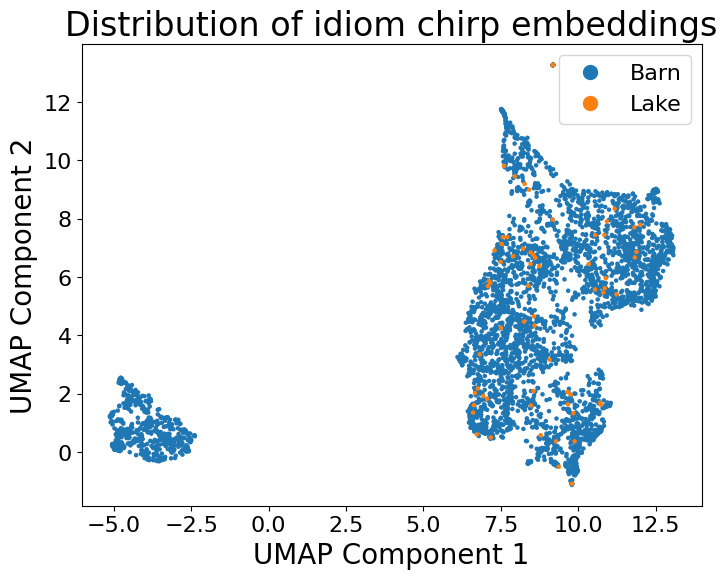

In [15]:
# FIGURE: 10.2

plt.figure(figsize=(8, 6))
scatter = plt.scatter(idiom_chirp_attributes_embedded[:, 0], 
                      idiom_chirp_attributes_embedded[:, 1], 
                      c=idiom_chirp_attributes["original_df"], 
                      cmap="tab10",
                      vmin=1,
                      vmax=10,
                      s=5,
                      )
plt.title(f"Distribution of idiom chirp embeddings")# in UMAP space")
handles, labels = scatter.legend_elements()
plt.legend(handles, [exp_1_name, exp_2_name])
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

Run clustering on the set of idiom chirps combined from both idioms:

In [16]:
MIN_K = 1
MAX_K = 50

n_clusters = find_ideal_cluster_k(idiom_chirp_attributes_embedded, MIN_K, MAX_K, plot=False)
n_clusters

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)
100%|██████████| 49/49 [00:13<00:00,  3.53it/s]


{'gap_statistic': 34,
 'diff_statistic': np.int64(3),
 'elbow_method': np.int64(7)}

In [17]:
clustering = "Agglomerative"
use_umap = True
NUM_CLUSTERS = n_clusters["elbow_method"]

cluster_data_input = idiom_chirp_attributes_embedded if use_umap else idiom_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy()
chirp_labels = cluster_chirps(cluster_data_input, clustering, use_umap, NUM_CLUSTERS)

chirp_labels

array([0, 6, 1, ..., 4, 6, 4], shape=(4067,))

In [18]:
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom,original_df
0,6,6,-0.758472,2.097561,0.342234,-0.130087,1.204148,0.140918,1.331267,-0.346128,...,0.702044,0.948214,0.214510,16694.0,1.0,4,False,False,False,1
1,7,7,-0.665949,0.512195,-0.331801,-0.278663,-0.216420,0.145049,-0.115885,-0.626173,...,-0.378525,-0.380798,0.094016,16694.0,2.0,2,False,False,False,1
2,8,8,-0.575578,0.463415,0.368835,0.444501,2.654516,-1.710903,-0.259207,0.125875,...,0.517256,0.097398,-0.599577,16694.0,3.0,2,False,False,False,1
3,9,9,-0.480904,0.560976,0.039443,0.031836,-0.275627,0.161046,0.559302,-1.043805,...,-0.028119,0.141137,0.166973,16694.0,4.0,5,False,False,False,1
4,10,10,-0.399139,0.268293,0.450995,0.461690,2.507363,-1.661045,0.601239,-0.593716,...,0.623593,0.494608,-0.587858,16694.0,5.0,2,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4062,14766,539,-0.919134,-2.000000,0.065337,0.229774,0.773140,-0.578888,0.226141,0.022621,...,1.377563,0.784006,-0.200507,1076.0,1.0,9,False,False,False,2
4063,14767,540,-0.810934,0.750000,-0.259159,-0.535788,0.567643,-0.523486,2.194753,-14.497424,...,2.096687,0.306679,-0.477417,1076.0,2.0,1,False,False,False,2
4064,14768,541,-0.733485,-0.600000,-0.786076,-0.752598,0.102882,-0.902756,-1.199308,1.321365,...,-0.501786,-0.787966,-0.403434,1076.0,3.0,1,False,False,False,2
4065,14769,542,-0.651481,-0.350000,-0.260059,-0.061770,-0.319921,0.448758,-0.749578,0.830821,...,-0.218128,-0.524312,0.924043,1076.0,4.0,3,False,False,False,2


In [19]:
import matplotlib 
from matplotlib.colors import ListedColormap

cmap1_colors = matplotlib.colormaps["tab10"](np.linspace(0, 1, 256))
cmap2_colors = cmap1_colors * 0.35
cmap2_colors[:, 3] = 1
cmap2_colors
cmap2 = ListedColormap(cmap2_colors, name="Set1dark")

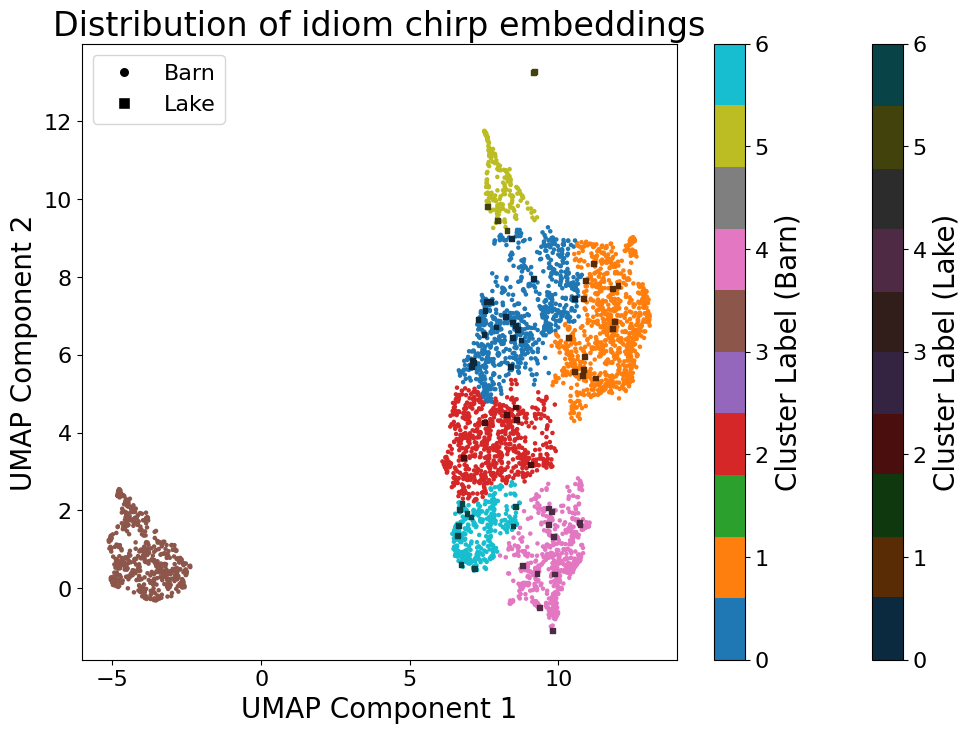

In [20]:
# FIGURE: 11.1

# plot the idiom chirps with their clusters, with the two experiments designated with different shapes
second_exp_first_row = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 2].iloc[0].name

plt.figure(figsize=(12, 8))
scatter1 = plt.scatter(idiom_chirp_attributes_embedded[:second_exp_first_row, 0], 
                      idiom_chirp_attributes_embedded[:second_exp_first_row, 1], 
                      c=chirp_labels[:second_exp_first_row], 
                      cmap="tab10", 
                      s=5, 
                      vmin=min(chirp_labels), 
                      vmax=NUM_CLUSTERS - 1
                      )
scatter2 = plt.scatter(idiom_chirp_attributes_embedded[second_exp_first_row:, 0], 
                      idiom_chirp_attributes_embedded[second_exp_first_row:, 1], 
                      c=chirp_labels[second_exp_first_row:], 
                      cmap=cmap2, 
                      s=12, 
                      marker="s",
                      vmin=min(chirp_labels), 
                      vmax=NUM_CLUSTERS - 1
                      )
plt.title(f"Distribution of idiom chirp embeddings")# in UMAP space")
# handles, labels = scatter1.legend_elements()
# plt.legend(handles, ["barn", "lake"])
plt.colorbar(scatter2, label=f"Cluster Label ({exp_2_name})")
plt.colorbar(scatter1, label=f"Cluster Label ({exp_1_name})")
legend_symbol_barn = matplotlib.lines.Line2D([0], [0], marker='.', color='w', label='Significant Peak', markerfacecolor='black', markersize=15)
legend_symbol_lake = matplotlib.lines.Line2D([0], [0], marker='s', color='w', label='Significant Peak', markerfacecolor='black', markersize=9)
plt.legend([legend_symbol_barn, legend_symbol_lake], [exp_1_name, exp_2_name])

plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

In [21]:
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom,original_df
0,6,6,-0.758472,2.097561,0.342234,-0.130087,1.204148,0.140918,1.331267,-0.346128,...,0.702044,0.948214,0.214510,16694.0,1.0,4,False,False,False,1
1,7,7,-0.665949,0.512195,-0.331801,-0.278663,-0.216420,0.145049,-0.115885,-0.626173,...,-0.378525,-0.380798,0.094016,16694.0,2.0,2,False,False,False,1
2,8,8,-0.575578,0.463415,0.368835,0.444501,2.654516,-1.710903,-0.259207,0.125875,...,0.517256,0.097398,-0.599577,16694.0,3.0,2,False,False,False,1
3,9,9,-0.480904,0.560976,0.039443,0.031836,-0.275627,0.161046,0.559302,-1.043805,...,-0.028119,0.141137,0.166973,16694.0,4.0,5,False,False,False,1
4,10,10,-0.399139,0.268293,0.450995,0.461690,2.507363,-1.661045,0.601239,-0.593716,...,0.623593,0.494608,-0.587858,16694.0,5.0,2,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4062,14766,539,-0.919134,-2.000000,0.065337,0.229774,0.773140,-0.578888,0.226141,0.022621,...,1.377563,0.784006,-0.200507,1076.0,1.0,9,False,False,False,2
4063,14767,540,-0.810934,0.750000,-0.259159,-0.535788,0.567643,-0.523486,2.194753,-14.497424,...,2.096687,0.306679,-0.477417,1076.0,2.0,1,False,False,False,2
4064,14768,541,-0.733485,-0.600000,-0.786076,-0.752598,0.102882,-0.902756,-1.199308,1.321365,...,-0.501786,-0.787966,-0.403434,1076.0,3.0,1,False,False,False,2
4065,14769,542,-0.651481,-0.350000,-0.260059,-0.061770,-0.319921,0.448758,-0.749578,0.830821,...,-0.218128,-0.524312,0.924043,1076.0,4.0,3,False,False,False,2


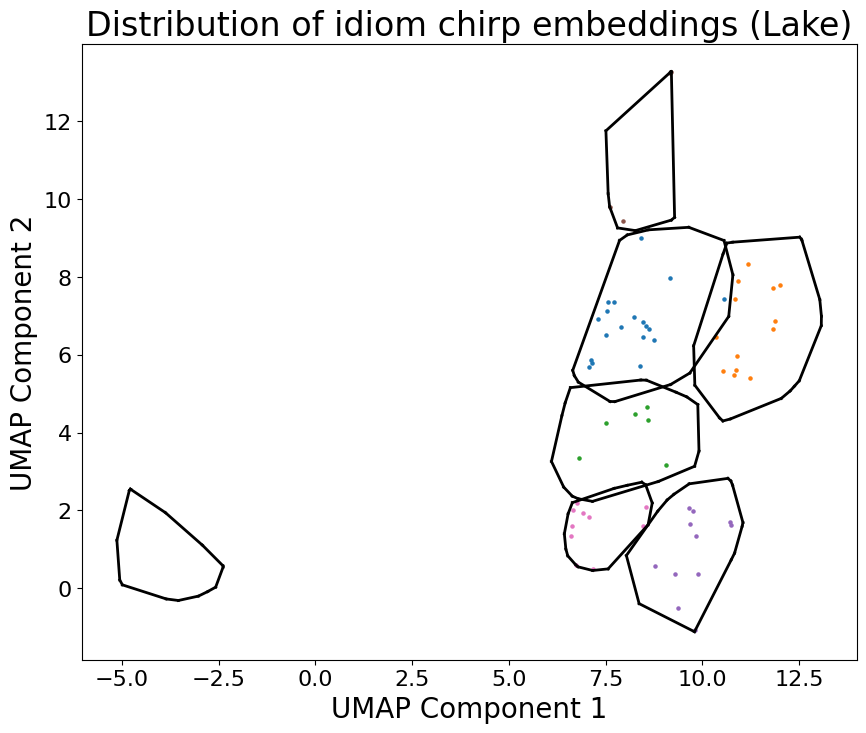

In [22]:
from scipy.spatial import ConvexHull
plt.figure(figsize=(10, 8))
idiom_chirp_attributes['cluster_idx'] = chirp_labels
exp_to_plot = 2

first_exp_attributes_embedded = idiom_chirp_attributes_embedded[:second_exp_first_row]
second_exp_attributes_embedded = idiom_chirp_attributes_embedded[second_exp_first_row:]
for i in range(NUM_CLUSTERS):
    cluster_points = idiom_chirp_attributes_embedded[idiom_chirp_attributes['cluster_idx'] == i]
    if len(cluster_points) > 2:
        hull = ConvexHull(cluster_points)
        # Plot the hull as a closed line
        for simplex in hull.simplices:
            plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], 'k-', lw=2, alpha=1) # 'k-' for a solid black line
    
    first_exp_cluster_points = first_exp_attributes_embedded[idiom_chirp_attributes['cluster_idx'][:second_exp_first_row] == i]
    second_exp_cluster_points = second_exp_attributes_embedded[idiom_chirp_attributes['cluster_idx'][second_exp_first_row:] == i]
    if exp_to_plot == 1:
        scatter = plt.scatter(first_exp_cluster_points[:, 0], first_exp_cluster_points[:, 1], s=5, label=f'Cluster {i}', alpha=1)
    else:
        scatter = plt.scatter(second_exp_cluster_points[:, 0], second_exp_cluster_points[:, 1], s=5, label=f'Cluster {i}', alpha=1)

plt.title(f"Distribution of idiom chirp embeddings ({exp_1_name if exp_to_plot == 1 else exp_2_name})")
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");

Evaluate various metrics about the clustering of the two sets of idiom chirps:

In [23]:
idiom_label_sequences = idiom_chirp_attributes.groupby(["file_id", "original_df"]).agg(list)["cluster_idx"].reset_index()
idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]

,file_id,original_df,cluster_idx
10,16694.0,1,"[0, 6, 1, 2, 1, 2, 1, 2, 4, 0]"
11,16696.0,1,"[2, 2, 2, 6, 6, 6]"
12,16697.0,1,"[5, 0, 0, 0, 0]"
13,16698.0,1,"[6, 2, 4, 4]"
14,16699.0,1,"[2, 4, 4]"
...,...,...,...
465,17304.0,1,"[2, 6, 6, 1, 3, 0, 1]"
466,17308.0,1,"[1, 0, 0, 1, 0, 6, 6, 1, 1, 2, 3]"
467,17309.0,1,[0]
468,17310.0,1,"[2, 6, 0, 1, 1, 1, 0]"


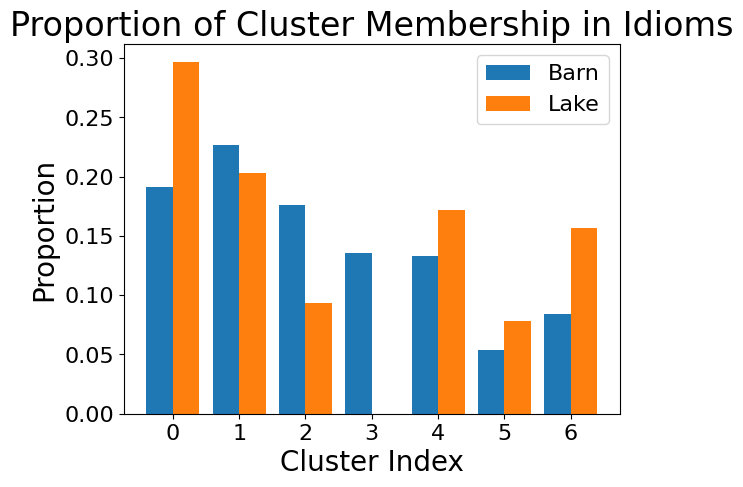

In [24]:
# FIGURE: 12.1

# plot a histogram of cluster indices across the two experiments
first_exp_clusters = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 1]['cluster_idx'].values
second_exp_clusters = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 2]['cluster_idx'].values
plt.hist([first_exp_clusters, second_exp_clusters], 
         bins=(np.arange(min(chirp_labels), max(chirp_labels) + 2) - 0.5), 
         density=True,
        #  stacked=True,
         )
plt.xticks(range(min(chirp_labels), max(chirp_labels) + 1))
plt.title(f"Proportion of Cluster Membership in Idioms")
plt.xlabel("Cluster Index")
plt.ylabel("Proportion")
plt.legend([exp_1_name, exp_2_name]);

In [25]:
# FIGURE: 12.2

# find the most common cluster across both experiments
LENGTH = 1
K_MOST_COMMON = 10
SUBSEQ_TYPE = "all"
subseq_all = most_common_subsequences(idiom_label_sequences['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE, 
                         k=K_MOST_COMMON)
subseq_exp1 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)
subseq_exp2 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 2]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)
subseq_all = pd.DataFrame(subseq_all, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} (all)', 'Count'])
subseq_exp1 = pd.DataFrame(subseq_exp1, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} ({exp_1_name})', 'Count'])
subseq_exp2 = pd.DataFrame(subseq_exp2, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} ({exp_2_name})', 'Count'])
res = pd.concat([subseq_all, subseq_exp1, subseq_exp2], axis=1)
res.insert(0, "Rank", range(1, len(res) + 1))
print(res)

   Rank Subseq (all)  Count Subseq (Barn)  Count Subseq (Lake)  Count
0     1         (1,)    921          (1,)    908          (0,)   19.0
1     2         (0,)    784          (0,)    765          (1,)   13.0
2     3         (2,)    712          (2,)    706          (4,)   11.0
3     4         (4,)    543          (3,)    542          (6,)   10.0
4     5         (3,)    542          (4,)    532          (2,)    6.0
5     6         (6,)    346          (6,)    336          (5,)    5.0
6     7         (5,)    219          (5,)    214           NaN    NaN


In [26]:
idiom_clusters_temp = []
idiom_clusters_temp_1 = []
idiom_clusters_temp_2 = []
for idx, row in idiom_label_sequences.iterrows():
    idiom_clusters_temp.extend(row['cluster_idx'])
    if row["original_df"] == 1:
        idiom_clusters_temp_1.extend(row['cluster_idx'])
    else:
        idiom_clusters_temp_2.extend(row['cluster_idx'])
idiom_cluster_counts_all = Counter(idiom_clusters_temp)
idiom_cluster_counts_1 = Counter(idiom_clusters_temp_1)
idiom_cluster_counts_2 = Counter(idiom_clusters_temp_2)

In [27]:
# FIGURE: 12.3

# find most common transitions
LENGTH = 2
subseq_all = most_common_subsequences(idiom_label_sequences['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE, 
                         k=K_MOST_COMMON)
subseq_exp1 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)
subseq_exp2 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 2]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type=SUBSEQ_TYPE,
                         k=K_MOST_COMMON)

# total_subseq_count_all = sum(most_common_subsequences(idiom_label_sequences['cluster_idx'].values, LENGTH, subseq_type=SUBSEQ_TYPE).values())
# total_subseq_count_exp1 = sum(most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]['cluster_idx'].values, LENGTH, subseq_type=SUBSEQ_TYPE).values())
# total_subseq_count_exp2 = sum(most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 2]['cluster_idx'].values, LENGTH, subseq_type=SUBSEQ_TYPE).values())

subseq_all = pd.DataFrame(subseq_all, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} (all)', 'Count'])
subseq_all_proportion = subseq_all.copy()
subseq_all_proportion['Start Cluster Count'] = subseq_all_proportion.apply(lambda x: idiom_cluster_counts_all[x['Subseq (all)'][0]], axis=1)
subseq_all_proportion['Transition Probability'] = subseq_all_proportion.apply(lambda x: x['Count'] / idiom_cluster_counts_all[x['Subseq (all)'][0]], axis=1)
subseq_all_proportion.drop(["Count", 'Start Cluster Count'], axis=1, inplace=True)
subseq_all_proportion = subseq_all_proportion.sort_values('Transition Probability', ascending=False).reset_index(drop=True)
subseq_all_proportion["Transition Probability"] = subseq_all_proportion["Transition Probability"].round(3)

subseq_exp1 = pd.DataFrame(subseq_exp1, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} ({exp_1_name})', 'Count'])
subseq_exp1_proportion = subseq_exp1.copy()
subseq_exp1_proportion['Start Cluster Count'] = subseq_exp1_proportion.apply(lambda x: idiom_cluster_counts_1[x['Subseq (Barn)'][0]], axis=1)
subseq_exp1_proportion['Transition Probability'] = subseq_exp1_proportion.apply(lambda x: x['Count'] / idiom_cluster_counts_1[x['Subseq (Barn)'][0]], axis=1)
subseq_exp1_proportion.drop(["Count", 'Start Cluster Count'], axis=1, inplace=True)
subseq_exp1_proportion = subseq_exp1_proportion.sort_values('Transition Probability', ascending=False).reset_index(drop=True)
subseq_exp1_proportion["Transition Probability"] = subseq_exp1_proportion["Transition Probability"].round(3)

subseq_exp2 = pd.DataFrame(subseq_exp2, columns=[f'{"Subseq" if SUBSEQ_TYPE == "all" else SUBSEQ_TYPE} ({exp_2_name})', 'Count'])
subseq_exp2_proportion = subseq_exp2.copy()
# subseq_exp2_proportion['Proportion'] = subseq_exp2_proportion['Count'] / total_subseq_count_exp2
subseq_exp2_proportion['Start Cluster Count'] = subseq_exp2_proportion.apply(lambda x: idiom_cluster_counts_2[x['Subseq (Lake)'][0]], axis=1)
subseq_exp2_proportion['Transition Probability'] = subseq_exp2_proportion.apply(lambda x: x['Count'] / idiom_cluster_counts_2[x['Subseq (Lake)'][0]], axis=1)
subseq_exp2_proportion.drop(["Count", 'Start Cluster Count'], axis=1, inplace=True)
subseq_exp2_proportion = subseq_exp2_proportion.sort_values('Transition Probability', ascending=False).reset_index(drop=True)
subseq_exp2_proportion["Transition Probability"] = subseq_exp2_proportion["Transition Probability"].round(3)

res = pd.concat([subseq_all, subseq_exp1, subseq_exp2], axis=1)
res.insert(0, "Rank", range(1, len(res) + 1))
res_proportion = pd.concat([subseq_all_proportion, subseq_exp1_proportion, subseq_exp2_proportion], axis=1)
res_proportion.insert(0, "Rank", range(1, len(res_proportion) + 1))
res_proportion.rename(columns = {f'Subseq ({exp_1_name})': f'{exp_1_name} Subseq', f'Subseq ({exp_2_name})': f'{exp_2_name} Subseq'}, inplace=True)
header=[['','All','',f'{exp_1_name}', '', f'{exp_2_name}', ''], ['Rank','Subseq','Proportion', 'Subseq','Proportion', 'Subseq','Proportion']]
res_proportion.columns=header
print(res_proportion)

           All               Barn               Lake           
  Rank  Subseq Proportion  Subseq Proportion  Subseq Proportion
0    1  (1, 1)      0.330  (1, 1)      0.333  (5, 0)      0.400
1    2  (0, 0)      0.291  (0, 0)      0.289  (0, 0)      0.368
2    3  (2, 2)      0.246  (2, 2)      0.246  (4, 6)      0.273
3    4  (4, 4)      0.227  (4, 4)      0.227  (0, 1)      0.263
4    5  (0, 1)      0.204  (0, 1)      0.203  (1, 0)      0.231
5    6  (2, 1)      0.187  (2, 1)      0.186  (1, 6)      0.231
6    7  (3, 1)      0.179  (3, 1)      0.179  (6, 0)      0.200
7    8  (1, 0)      0.177  (1, 0)      0.176  (6, 2)      0.200
8    9  (3, 2)      0.168  (3, 2)      0.168  (4, 4)      0.182
9   10  (1, 2)      0.153  (1, 2)      0.153  (0, 4)      0.105


Stepping away from comparison for a second, this section allows us to describe the characteristics of a given cluster

In [29]:
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,cluster,idiom_start,idiom_end,in_idiom,original_df,cluster_idx
0,6,6,-0.758472,2.097561,0.342234,-0.130087,1.204148,0.140918,1.331267,-0.346128,...,0.948214,0.214510,16694.0,1.0,4,False,False,False,1,0
1,7,7,-0.665949,0.512195,-0.331801,-0.278663,-0.216420,0.145049,-0.115885,-0.626173,...,-0.380798,0.094016,16694.0,2.0,2,False,False,False,1,6
2,8,8,-0.575578,0.463415,0.368835,0.444501,2.654516,-1.710903,-0.259207,0.125875,...,0.097398,-0.599577,16694.0,3.0,2,False,False,False,1,1
3,9,9,-0.480904,0.560976,0.039443,0.031836,-0.275627,0.161046,0.559302,-1.043805,...,0.141137,0.166973,16694.0,4.0,5,False,False,False,1,2
4,10,10,-0.399139,0.268293,0.450995,0.461690,2.507363,-1.661045,0.601239,-0.593716,...,0.494608,-0.587858,16694.0,5.0,2,False,False,False,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4062,14766,539,-0.919134,-2.000000,0.065337,0.229774,0.773140,-0.578888,0.226141,0.022621,...,0.784006,-0.200507,1076.0,1.0,9,False,False,False,2,0
4063,14767,540,-0.810934,0.750000,-0.259159,-0.535788,0.567643,-0.523486,2.194753,-14.497424,...,0.306679,-0.477417,1076.0,2.0,1,False,False,False,2,5
4064,14768,541,-0.733485,-0.600000,-0.786076,-0.752598,0.102882,-0.902756,-1.199308,1.321365,...,-0.787966,-0.403434,1076.0,3.0,1,False,False,False,2,4
4065,14769,542,-0.651481,-0.350000,-0.260059,-0.061770,-0.319921,0.448758,-0.749578,0.830821,...,-0.524312,0.924043,1076.0,4.0,3,False,False,False,2,6


In [ ]:
ignore_columns = ["index", "OriginalIndex", "file_id", "chirp_idx", "original_df", "cluster_idx"]
cluster_profile = describe_cluster(idiom_chirp_attributes, 7, normalize=False, ignore_columns=ignore_columns)
cluster_profile

TimeInFile         0.091719
PrecedingIntrvl    0.071402
HiFreq            -0.454323
Bndwdth           -0.479523
FreqMaxPwr         0.044930
PrcntMaxAmpDur     0.134496
FreqKnee          -0.346752
PrcntKneeDur       0.239385
StartF            -0.454154
UpprKnFreq        -0.205054
HiFtoUpprKnAmp    -0.303121
HiFtoKnAmp        -0.292172
HiFtoFcAmp        -0.208581
UpprKnToKnAmp      0.177677
KnToFcAmp         -0.105459
LdgToFcAmp         0.180108
FreqCtr           -0.047582
FFwd32dB           1.242814
FFwd20dB           0.048039
FFwd15dB           0.055117
FBak5dB            0.076739
FFwd5dB            0.050604
Bndw32dB           2.433425
Amp1stQrtl         0.481829
Amp2ndQrtl        -0.051971
Amp3rdQrtl        -0.240475
Amp4thQrtl         0.343501
1st10kHzSlp       -0.426429
1st5to15kHzSlp    -0.428017
1st10kHzExp       -0.313858
1st5to15kHzExp    -0.333817
AmpK@start         0.681414
cluster            7.000000
idiom_start        0.011804
idiom_end          0.005059
in_idiom           0